In [1]:
import massPy as mp
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm
from skimage import measure
from scipy.ndimage import convolve
import pandas as pd

import scienceplots
plt.style.use(['science','nature'])

# List of JSON paths

# json_paths = [
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_2/phi0-3",
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_2/phi0-35",
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_2/phi0-4",
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_2/phi0-45",
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_2/phi0-5",
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_2/phi0-55",
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_2/phi0-6",
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_2/phi0-65",
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_2/phi0-7"
# ]

# json_paths = [
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_1/phi0-3",
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_1/phi0-35",
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_1/phi0-4",
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_1/phi0-45",
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_1/phi0-5",
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_1/phi0-55",
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_1/phi0-6",
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_1/phi0-65",
#     "/Volumes/Tianxiang/update/phi/phi_zeta2e-2_1/phi0-7"
# ]

json_paths = [
    "/Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-3",
    "/Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-35",
    "/Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-4",
    "/Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-45",
    "/Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-5",
    "/Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-55",
    "/Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-6",
    "/Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-65",
    "/Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-7"
]


# json_paths = [
#     "/Volumes/Tianxiang/phi-good/phi0",
#     "/Volumes/Tianxiang/phi-good/phi0-1",
#     "/Volumes/Tianxiang/phi-good/phi0-2",
#     "/Volumes/Tianxiang/phi-good/phi0-3",
#     "/Volumes/Tianxiang/phi-good/phi0-4",
#     "/Volumes/Tianxiang/phi-good/phi0-5",
#     "/Volumes/Tianxiang/phi-good/phi0-6",
#     "/Volumes/Tianxiang/phi-good/phi0-7",
#     "/Volumes/Tianxiang/phi-good/phi0-8",
#     "/Volumes/Tianxiang/phi-good/phi0-9",
#     "/Volumes/Tianxiang/phi-good/phi1"
# ]

# Define output directories
save_path = "/Volumes/Tianxiang/update/phi/phi_zeta2e-2/output_new"
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Define the range of frames to average
start_frame, end_frame = 350, 400
frame_count = end_frame - start_frame


In [6]:
velocity_save_path = os.path.join(save_path, "velocity")
if not os.path.exists(velocity_save_path):
    os.makedirs(velocity_save_path)

# List to collect mean velocity for each json path
mean_velocity_list = []

# Process each JSON path
for json_path in json_paths:
    print(f"Processing {json_path}...")
    
    ar = mp.archive.loadarchive(json_path)
    n = ar.num_frames
    lx, ly = ar.LX, ar.LY
        
    # Initialize accumulator for velocity magnitude
    velocity_sum = None
    
    # Loop over frames
    for ni in range(start_frame, end_frame):
        frame = ar._read_frame(ni)  
        
        # Compute velocity components.
        vx, vy = mp.base_modules.flow.velocity(frame.ff, lx, ly)
        
        # Calculate velocity magnitude.
        velocity_mag = np.sqrt(vx**2 + vy**2)
        
        # Accumulate the velocity magnitude.
        if velocity_sum is None:
            velocity_sum = velocity_mag
        else:
            velocity_sum += velocity_mag
            
    # Compute the average velocity magnitude over the frames.
    velocity_mag_avg = velocity_sum / frame_count
    
    # Plotting the averaged velocity magnitude with custom figure size
    mm = 1 / 25.4
    fig, ax = plt.subplots(figsize=(30 * mm, 30 * mm), dpi=300)
    im = ax.imshow(velocity_mag_avg.T, origin='lower', cmap='jet', alpha=1, vmin=0, vmax=0.004)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, orientation='vertical')
    cb.ax.tick_params(labelsize=6)
    cb.set_label("Velocity magnitude", fontsize=6)

    # ax.set_title("Average Velocity Magnitude")
    # ax.set_xlabel('X', fontsize=7)
    # ax.set_ylabel('Y', fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    # ax.set_xticks(np.arange(0, lx + 1, 50))
    # ax.set_yticks(np.arange(0, ly + 1, 50))
    # ax.tick_params(axis='both', which='major', labelsize=7)
    
    
    # Use the base name of the json path to create a unique filename.
    json_name = os.path.basename(json_path.rstrip('/'))
    plot_filename = os.path.join(velocity_save_path, f"{json_name}_velocity.png")
    fig.savefig(plot_filename, dpi=300)
    plt.close(fig)
    
    # Calculate the overall mean velocity magnitude for this json path.
    overall_mean = np.nanmean(velocity_mag_avg)
    mean_velocity_list.append({"json_path": json_path, "mean_velocity": overall_mean})

# Save the collected mean velocities into a CSV file.
df = pd.DataFrame(mean_velocity_list)
csv_filename = os.path.join(velocity_save_path, "mean_velocity.csv")
df.to_csv(csv_filename, index=False)
print("Processing complete. CSV file saved at:", csv_filename)

Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-3...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-35...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-4...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-45...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-5...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-55...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-6...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-65...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-7...
Processing complete. CSV file saved at: /Volumes/Tianxiang/update/phi/phi_zeta2e-2/output_new/velocity/mean_velocity.csv


                                           json_path  mean_velocity
0  /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-3       0.002109
1  /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi...       0.001884
2  /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-4       0.001691
3  /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi...       0.001486
4  /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-5       0.001439
       mean_velocity
count       9.000000
mean        0.001330
std         0.000518
min         0.000649
25%         0.000933
50%         0.001439
75%         0.001691
max         0.002109


/var/folders/cb/scnh6zzn3wb9s4gmkvv99llm0000gn/T/ipykernel_52688/2588721129.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


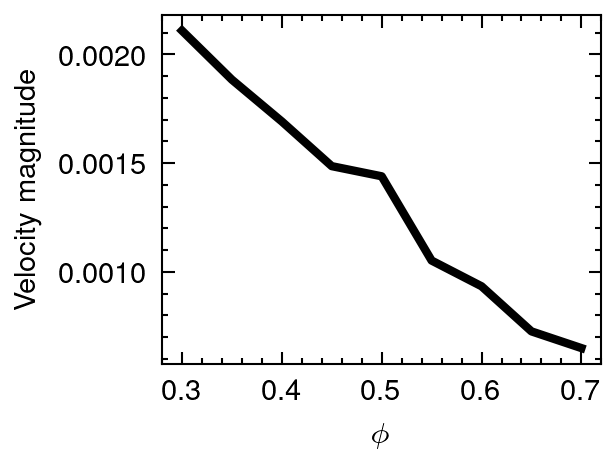

In [ ]:
import pandas as pd

# Read the CSV and display its head and description
csv_df = pd.read_csv(csv_filename)
print(csv_df.head())
print(csv_df.describe())

# Plot mean velocity vs φ
mm = 1 / 25.4
fig, ax = plt.subplots(figsize=(60 * 0.8 * mm, 48 * 0.8 * mm), dpi=300)

# Generate phi values assuming they correspond to the order of JSON paths.
phi_values = np.linspace(0.3, 0.7, len(df))
color = 'black'
ax.plot(phi_values, df['mean_velocity'], '-', linewidth=2, color=color)

ax.set_xlabel('$\\phi$', fontsize=7)
ax.set_ylabel('Velocity magnitude', fontsize=7)
ax.legend(fontsize=7)
ax.tick_params(axis='both', which='major', labelsize=7)

plot_path = os.path.join(velocity_save_path, "mean_velocity.png")
fig.savefig(plot_path, dpi=300)

plt.show()

# stress director + J2

In [5]:
from scipy.ndimage import convolve

J2_save_path = os.path.join(save_path, "J2")
if not os.path.exists(J2_save_path):
    os.makedirs(J2_save_path)

# Process each JSON path
for json_path in json_paths:
    print(f"Processing {json_path}...")

    ar = mp.archive.loadarchive(json_path)
    n = ar.num_frames
    lx, ly = ar.LX, ar.LY

    # Initialize accumulators
    J2_sum = np.zeros((lx, ly))
    
    # Loop over frames
    for ni in range(start_frame, end_frame):
        frame = ar._read_frame(ni)

        sigma_xx = frame.sigmaXX.reshape(lx, ly)
        sigma_yy = frame.sigmaYY.reshape(lx, ly)
        sigma_xy = 0.5 * (frame.sigmaXY.reshape(lx, ly) + frame.sigmaYX.reshape(lx, ly))
        
        I1 = sigma_xx + sigma_yy  # trace of the stress tensor
        J2 = 0.5 * ((sigma_xx - I1/2.0)**2 + (sigma_yy - I1/2.0)**2 + 2 * sigma_xy**2)  # J2

        # Accumulate the stress components
        J2_sum += J2

        tau = sigma_xy # shear stress
        theta_max = 0.5 * np.arctan2(2 * tau, sigma_xx - sigma_yy) # angle of the max principal stress
        theta_max = np.mod(theta_max, np.pi)
        
        # Compute the stress order (sadly, sensitive to the windows size r)
        r = 6
        y_grid, x_grid = np.ogrid[-r:r+1, -r:r+1]
        mask = (x_grid**2 + y_grid**2) <= r**2
        kernel = mask.astype(float)
        kernel /= kernel.sum()
        local_cos = convolve(np.cos(2 * theta_max), kernel, mode='reflect')
        local_sin = convolve(np.sin(2 * theta_max), kernel, mode='reflect')


    # Compute the average stress components over the frames.
    mean_J2 = J2_sum / frame_count
    
    mm = 1 / 25.4
    fig, ax = plt.subplots(figsize=(30 * mm, 30 * mm), dpi=300)

    # Grid setup
    x, y = np.meshgrid(np.arange(lx), np.arange(ly))
    u = np.cos(theta_max)
    v = np.sin(theta_max)

    # Downsample grid for clarity (adjust step size as needed)
    step = 6
    x_down = x[::step, ::step]
    y_down = y[::step, ::step]
    u_down = u[::step, ::step]
    v_down = v[::step, ::step]

    # Length of each line segment
    scale = 5  # Adjust for visualization

    for i in range(x_down.shape[0]):
        for j in range(x_down.shape[1]):
            xc, yc = x_down[i, j], y_down[i, j]  # Center of line segment
            dx = u_down[i, j] * scale / 2  # Half-length along x
            dy = v_down[i, j] * scale / 2  # Half-length along y

            # Compute line segment endpoints
            x1, y1 = xc - dx, yc - dy
            x2, y2 = xc + dx, yc + dy

            # Plot line segment
            # ax.plot([y1, y2], [x1, x2], color='red', linewidth=0.5, alpha=0.8)

    # Background image
    im = ax.imshow(mean_J2.T, origin='lower', cmap='YlGnBu_r', alpha=1, vmin=0, vmax=3e-5)

    # Colorbar settings
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, orientation='vertical')
    cb.set_label(r"$J_2$", fontsize=6)
    cb.ax.tick_params(labelsize=6)

    # Axis settings
    # ax.set_xticks(np.arange(0, lx + 1, 50))
    # ax.set_yticks(np.arange(0, ly + 1, 50))
    # ax.tick_params(axis='both', which='major', labelsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # Save plot
    json_name = os.path.basename(json_path.rstrip('/'))
    plot_filename = os.path.join(J2_save_path, f"{json_name}_J2.png")
    fig.savefig(plot_filename, dpi=300)
    plt.close(fig)  

Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-3...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-35...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-4...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-45...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-5...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-55...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-6...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-65...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-7...


# nematic/stress order

In [6]:
nematic_save_path = os.path.join(save_path, "nematic")
if not os.path.exists(nematic_save_path):
    os.makedirs(nematic_save_path)

# List to collect mean velocity for each json path
mean_nematic_order_list = []
mean_stress_order_list = []

# Process each JSON path
for json_path in json_paths:
    print(f"Processing {json_path}...")
    
    ar = mp.archive.loadarchive(json_path)
    n = ar.num_frames
    lx, ly = ar.LX, ar.LY
        
    # Initialize accumulator for nematic order
    S_nematic_sum = None
    S_stress_sum = None
    
    # Loop over frames
    for ni in range(start_frame, end_frame):
        frame = ar._read_frame(ni)
        S, nx, ny = mp.nematic.nematicPy.get_director(frame.QQxx, frame.QQyx)
        S = S.reshape(lx, ly)
        # Accumulate the nematic order.
        if S_nematic_sum is None:
            S_nematic_sum = S
        else:
            S_nematic_sum += S
            
        sigma_xx = frame.sigmaXX.reshape(lx, ly)
        sigma_yy = frame.sigmaYY.reshape(lx, ly)
        sigma_xy = frame.sigmaXY.reshape(lx, ly)
        sigma_yx = frame.sigmaYX.reshape(lx, ly)
        tau = 0.5 * (sigma_xy + sigma_yx) # shear stress
        theta_max = 0.5 * np.arctan2(2 * tau, sigma_xx - sigma_yy) # angle of the max principal stress
        theta_max = np.mod(theta_max, np.pi)
        
        # Compute the stress order (sadly, sensitive to the windows size r)
        r = 6
        y_grid, x_grid = np.ogrid[-r:r+1, -r:r+1]
        mask = (x_grid**2 + y_grid**2) <= r**2
        kernel = mask.astype(float)
        kernel /= kernel.sum()
        local_cos = convolve(np.cos(2 * theta_max), kernel, mode='reflect')
        local_sin = convolve(np.sin(2 * theta_max), kernel, mode='reflect')
        S_stress = np.sqrt(local_cos**2 + local_sin**2)
        # Accumulate the stress order.
        if S_stress_sum is None:
            S_stress_sum = S_stress
        else:
            S_stress_sum += S_stress

    # Compute the average velocity magnitude over the frames.
    S_nematic_avg = S_nematic_sum / frame_count
    S_stress_avg = S_stress_sum / frame_count

    # Plotting the averaged nematic order
    mm = 1 / 25.4
    fig, ax = plt.subplots(figsize=(30 * mm, 30 * mm), dpi=300)
    im = ax.imshow(S_nematic_avg.T, origin='lower', cmap='inferno', alpha=1, vmin=0, vmax=0.5)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, orientation='vertical')
    cb.set_label("S", fontsize=6)
    cb.ax.tick_params(labelsize=6)
    # ax.set_title("Average Nematic Order")
    # ax.set_xlabel('X', fontsize=7)
    # ax.set_ylabel('Y', fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    # ax.set_xticks(np.arange(0, lx + 1, 50))
    # ax.set_yticks(np.arange(0, ly + 1, 50))
    # ax.tick_params(axis='both', which='major', labelsize=7)
    
    # Use the base name of the json path to create a unique filename.
    json_name = os.path.basename(json_path.rstrip('/'))
    plot_filename = os.path.join(nematic_save_path, f"{json_name}_nematic-order.png")
    fig.savefig(plot_filename, dpi=300)
    plt.close(fig)
    
    # Calculate the overall mean velocity magnitude for this json path.
    overall_nematic_mean = np.nanmean(S_nematic_avg)
    mean_nematic_order_list.append({"json_path": json_path, "mean_nematic-order": overall_nematic_mean})
    
    # Plotting the averaged stress order
    mm = 1 / 25.4
    fig, ax = plt.subplots(figsize=(30 * mm, 30 * mm), dpi=300)
    im = ax.imshow(S_stress_avg.T, origin='lower', cmap='inferno', alpha=1, vmin=0, vmax=1)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, orientation='vertical')
    cb.set_label("S", fontsize=6)
    cb.ax.tick_params(labelsize=6)
    # ax.set_title("Average Stress Order")
    # ax.set_xlabel('X', fontsize=7)
    # ax.set_ylabel('Y', fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    # ax.set_xticks(np.arange(0, lx + 1, 50))
    # ax.set_yticks(np.arange(0, ly + 1, 50))
    # ax.tick_params(axis='both', which='major', labelsize=7)
    
    # Use the base name of the json path to create a unique filename.
    json_name = os.path.basename(json_path.rstrip('/'))
    plot_filename = os.path.join(nematic_save_path, f"{json_name}_stress-order.png")
    fig.savefig(plot_filename, dpi=300)
    plt.close(fig)
    
    # Calculate the overall mean velocity magnitude for this json path.
    overall_stress_mean = np.nanmean(S_stress_avg)
    mean_stress_order_list.append({"json_path": json_path, "mean_stress-order": overall_stress_mean})

# Save the collected mean velocities into a CSV file.
df = pd.DataFrame(mean_nematic_order_list)
csv_nematic_filename = os.path.join(nematic_save_path, "mean_nematic_S.csv")
df.to_csv(csv_nematic_filename, index=False)
print("Processing complete. CSV file saved at:", csv_nematic_filename)

df = pd.DataFrame(mean_stress_order_list)
csv_stress_filename = os.path.join(nematic_save_path, "mean_stress_S.csv")
df.to_csv(csv_stress_filename, index=False)
print("Processing complete. CSV file saved at:", csv_stress_filename)


Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-3...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-35...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-4...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-45...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-5...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-55...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-6...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-65...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-7...
Processing complete. CSV file saved at: /Volumes/Tianxiang/update/phi/phi_zeta2e-2/output/nematic/mean_nematic_S.csv
Processing complete. CSV file saved at: /Volumes/Tianxiang/update/phi/phi_zeta2e-2/output/nematic/mean_stress_S.csv


                                           json_path  mean_nematic-order
0  /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-3            0.381373
1  /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi...            0.363315
2  /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-4            0.340011
3  /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi...            0.327721
4  /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-5            0.316537
       mean_nematic-order
count            9.000000
mean             0.300114
std              0.061378
min              0.202711
25%              0.255181
50%              0.316537
75%              0.340011
max              0.381373
                                           json_path  mean_stress-order
0  /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-3           0.694882
1  /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi...           0.690766
2  /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-4           0.685556
3  /Volumes/Tianxiang/update/phi/phi_zet

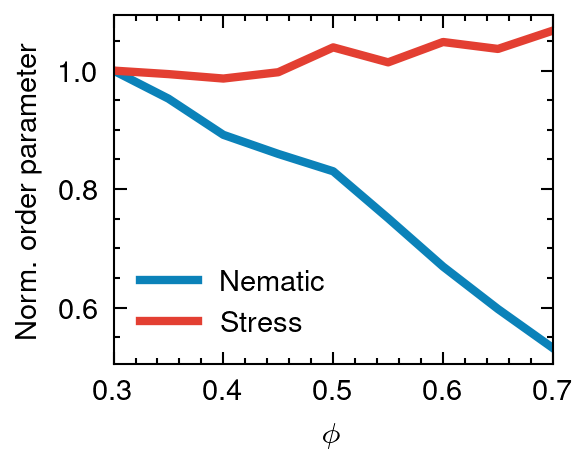

In [67]:
# Read the CSV and display its head and description
csv_nematic_df = pd.read_csv(csv_nematic_filename)
print(csv_nematic_df.head())
print(csv_nematic_df.describe())
csv_stress_df = pd.read_csv(csv_stress_filename)
print(csv_stress_df.head())
print(csv_stress_df.describe())

df = pd.DataFrame({
    'mean_nematic-order': csv_nematic_df['mean_nematic-order'],
    'mean_stress-order': csv_stress_df['mean_stress-order']
})

phi_values = np.linspace(0.3, 0.7, len(df))

# normalize
nematic_norm = df['mean_nematic-order'] / df['mean_nematic-order'].iloc[0]
stress_norm = df['mean_stress-order'] / df['mean_stress-order'].iloc[0]

# Plot mean velocity vs φ
mm = 1 / 25.4
fig, ax = plt.subplots(figsize=(60 * 0.8 * mm, 48 * 0.8 * mm), dpi=300)
ax.plot(phi_values, nematic_norm, '-', linewidth=2, color='#0B82B9', label='Nematic')
ax.plot(phi_values, stress_norm, '-', linewidth=2, color='#E33F32', label='Stress')
ax.set_xlabel('$\\phi$', fontsize=7)
ax.set_ylabel('Norm. order parameter', fontsize=7)
ax.legend(fontsize=7)
ax.tick_params(axis='both', which='major', labelsize=7)
# ax.set_ylim(0, 1.5)
ax.set_xlim(0.3, .7)

plot_path = os.path.join(nematic_save_path, "mean_nematic-stress-order.png")
fig.savefig(plot_path, dpi=300)

plt.show()

# passive order and comparison between tot

In [68]:
passive_save_path = os.path.join(save_path, "passive")
if not os.path.exists(passive_save_path):
    os.makedirs(passive_save_path)

# List to collect mean velocity for each json path
mean_passive_order_list = []

# Process each JSON path
for json_path in json_paths:
    print(f"Processing {json_path}...")

    ar = mp.archive.loadarchive(json_path)
    n = ar.num_frames
    lx, ly = ar.LX, ar.LY
        
    # Initialize accumulator for nematic order
    S_passive_stress_sum = None
    
    # Loop over frames
    for ni in range(start_frame, end_frame):
        frame = ar._read_frame(ni)
            
        sigma_xx = frame.sigmaXX.reshape(lx, ly)
        sigma_yy = frame.sigmaYY.reshape(lx, ly)
        sigma_xy = frame.sigmaXY.reshape(lx, ly)
        sigma_yx = frame.sigmaYX.reshape(lx, ly)
        
        # sigma_elastic_xx = frame.sigma_elastic_xx.reshape(lx, ly) + frame.sigma_phase_field_xx.reshape(lx, ly)
        # sigma_elastic_yx = frame.sigma_elastic_yx.reshape(lx, ly) + frame.sigma_phase_field_yx.reshape(lx, ly)
        # # sigma_elastic_xx = frame.sigma_phase_field_xx.reshape(lx, ly)
        # # sigma_elastic_yx = frame.sigma_phase_field_yx.reshape(lx, ly)      
        
        # sigma_passive_xx = sigma_elastic_xx
        # sigma_passive_yy = -sigma_elastic_xx
        # sigma_passive_xy = sigma_elastic_yx
        # sigma_passive_yx = sigma_elastic_yx
        
        sigma_active_xx = frame.sigma_active_xx.reshape(lx, ly)
        sigma_active_yx = frame.sigma_active_yx.reshape(lx, ly)
        sigma_passive_xx = sigma_xx - sigma_active_xx - frame.sigma_bulk.reshape(lx, ly)
        sigma_passive_yy = sigma_yy + sigma_active_xx - frame.sigma_bulk.reshape(lx, ly)
        sigma_passive_xy = sigma_xy - sigma_active_yx
        sigma_passive_yx = sigma_xy - sigma_active_yx

        I1 = sigma_xx + sigma_yy  # trace of the stress tensor
        tau = 0.5 * (sigma_xy + sigma_yx)  # shear stress
        sigma_avg = I1 / 2.0
        R = np.sqrt(((sigma_xx - sigma_yy) / 2.0)**2 + tau**2)
        sigma_max = sigma_avg + R
        sigma_min = sigma_avg - R
        theta_max = 0.5 * np.arctan2(2 * tau, sigma_xx - sigma_yy)
        theta_max = np.mod(theta_max, np.pi)

        I1_passive = sigma_passive_xx + sigma_passive_yy  # trace of the stress tensor
        tau_passive = 0.5 * (sigma_passive_xy + sigma_passive_yx)  # shear stress
        sigma_passive_avg = I1_passive / 2.0
        R_passive = np.sqrt(((sigma_passive_xx - sigma_passive_yy) / 2.0)**2 + tau_passive**2)
        sigma_passive_max = sigma_passive_avg + R_passive
        sigma_passive_min = sigma_passive_avg - R_passive
        theta_passive_max = 0.5 * np.arctan2(2 * tau_passive, sigma_passive_xx - sigma_passive_yy)
        theta_passive_max = np.mod(theta_passive_max, np.pi)
        
        r = 1
        y_grid, x_grid = np.ogrid[-r:r+1, -r:r+1]
        mask = (x_grid**2 + y_grid**2) <= r**2
        kernel = mask.astype(float)
        kernel /= kernel.sum()
        local_passive_cos = convolve(np.cos(2 * theta_passive_max), kernel, mode='reflect')
        local_passive_sin = convolve(np.sin(2 * theta_passive_max), kernel, mode='reflect')
        S_passive_stress = np.sqrt(local_passive_cos**2 + local_passive_sin**2)
        # Accumulate the stress order.
        if S_passive_stress_sum is None:
            S_passive_stress_sum = S_passive_stress
        else:
            S_passive_stress_sum += S_passive_stress

    # Compute the average velocity magnitude over the frames.
    S_passive_avg = S_passive_stress_sum / frame_count

    # Plotting the averaged stress order
    mm = 1 / 25.4
    fig, ax = plt.subplots(figsize=(48 * mm, 48 * mm), dpi=300)
    im = ax.imshow(S_passive_avg.T, origin='lower', cmap='cividis', alpha=1)
    cb = fig.colorbar(im, ax=ax, shrink=0.8)
    cb.set_label("S", fontsize=6)
    cb.ax.tick_params(labelsize=6)
    # ax.set_title("Average Stress Order")
    ax.set_xlabel('X', fontsize=7)
    ax.set_ylabel('Y', fontsize=7)
    ax.set_xticks(np.arange(0, lx + 1, 50))
    ax.set_yticks(np.arange(0, ly + 1, 50))
    ax.tick_params(axis='both', which='major', labelsize=7)
    
    # Use the base name of the json path to create a unique filename.
    json_name = os.path.basename(json_path.rstrip('/'))
    plot_filename = os.path.join(passive_save_path, f"{json_name}_passive-stress-order.png")
    fig.savefig(plot_filename, dpi=300)
    plt.close(fig)
    
    # Calculate the overall mean velocity magnitude for this json path.
    overall_passive_stress_mean = np.nanmean(S_passive_avg)
    mean_passive_order_list.append({"json_path": json_path, "mean_passive-stress-order": overall_passive_stress_mean})

# Save the collected mean velocities into a CSV file.
df = pd.DataFrame(mean_passive_order_list)
csv_passive_stress_filename = os.path.join(passive_save_path, "mean_passive-stress_S.csv")
df.to_csv(csv_passive_stress_filename, index=False)
print("Processing complete. CSV file saved at:", csv_passive_stress_filename)


Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-3...


Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-35...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-4...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-45...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-5...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-55...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-6...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-65...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-7...
Processing complete. CSV file saved at: /Volumes/Tianxiang/update/phi/phi_zeta2e-2/output/passive/mean_passive-stress_S.csv


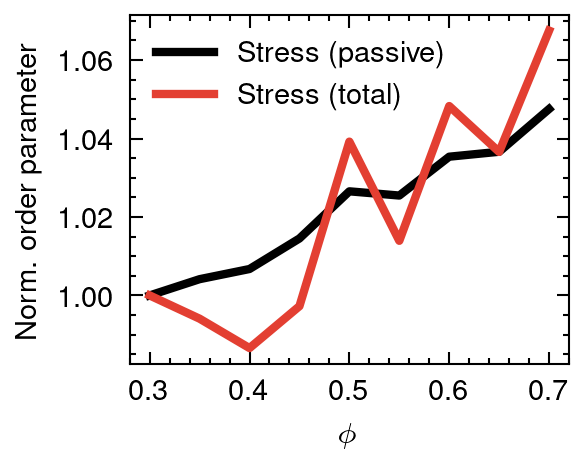

In [69]:
# Read the CSV and display its head and description
csv_passive_df = pd.read_csv(csv_passive_stress_filename)
csv_stress_df = pd.read_csv(csv_stress_filename)

df = pd.DataFrame({
    'mean_passive-stress-order': csv_passive_df['mean_passive-stress-order'],
    'mean_stress-order': csv_stress_df['mean_stress-order']
})

phi_values = np.linspace(0.3, 0.7, len(df))

# normalize
passive_norm = df['mean_passive-stress-order'] / df['mean_passive-stress-order'].iloc[0]
stress_norm = df['mean_stress-order'] / df['mean_stress-order'].iloc[0]

# Plot mean velocity vs φ
mm = 1 / 25.4
fig, ax = plt.subplots(figsize=(60 * 0.8 * mm, 48 * 0.8 * mm), dpi=300)
ax.plot(phi_values, passive_norm, '-', linewidth=2, color='black', label='Stress (passive)')
ax.plot(phi_values, stress_norm, '-', linewidth=2, color='#E33F32', label='Stress (total)')
ax.set_xlabel('$\\phi$', fontsize=7)
ax.set_ylabel('Norm. order parameter', fontsize=7)
ax.legend(fontsize=7)
ax.tick_params(axis='both', which='major', labelsize=7)
# ax.set_ylim(0, 1.5)

plot_path = os.path.join(passive_save_path, "mean_stress-order.png")
fig.savefig(plot_path, dpi=300)

plt.show()

# passive contribution

In [70]:
passive_save_path = os.path.join(save_path, "passive_contribute")
if not os.path.exists(passive_save_path):
    os.makedirs(passive_save_path)

mean_passive_order_list = []
mean_passive_contribution_list = []  # contribution of passive stress

for json_path in json_paths:
    print(f"Processing {json_path}...")

    ar = mp.archive.loadarchive(json_path)
    n = ar.num_frames
    lx, ly = ar.LX, ar.LY

    S_passive_stress_sum = None
    passive_contribution_sum = None  
    
    for ni in range(start_frame, end_frame):
        frame = ar._read_frame(ni)

        sigma_xx = frame.sigmaXX.reshape(lx, ly)
        sigma_yy = frame.sigmaYY.reshape(lx, ly)
        sigma_xy = frame.sigmaXY.reshape(lx, ly)
        sigma_yx = frame.sigmaYX.reshape(lx, ly)

        # sigma_passive_xx = frame.sigma_elastic_xx.reshape(lx, ly) + frame.sigma_bulk.reshape(lx, ly)
        # sigma_passive_yx = frame.sigma_elastic_yx.reshape(lx, ly)
        # sigma_passive_yy = -sigma_elastic_xx
    
        # sigma_passive_xx = sigma_elastic_xx
        # sigma_passive_yy = -sigma_elastic_xx
        # sigma_passive_xy = sigma_elastic_yx
        # sigma_passive_yx = sigma_elastic_yx
        
        sigma_active_xx = frame.sigma_active_xx.reshape(lx, ly)
        sigma_active_yx = frame.sigma_active_yx.reshape(lx, ly)
        
        # sigma_passive_xx = sigma_xx - sigma_active_xx - frame.sigma_bulk.reshape(lx, ly)
        # sigma_passive_yy = sigma_yy + sigma_active_xx - frame.sigma_bulk.reshape(lx, ly)
        sigma_passive_xx = sigma_xx - sigma_active_xx
        sigma_passive_yy = sigma_yy + sigma_active_xx
        sigma_passive_xy = sigma_xy - sigma_active_yx
        sigma_passive_yx = sigma_xy - sigma_active_yx
        
        I1_passive = sigma_passive_xx + sigma_passive_yy  # trace of the stress tensor
        tau_passive = sigma_passive_yx  # shear stress
        sigma_passive_avg = I1_passive / 2.0
        R_passive = np.sqrt(((sigma_passive_xx - sigma_passive_yy) / 2.0)**2 + tau_passive**2)
        sigma_passive_max = sigma_passive_avg + R_passive
        sigma_passive_min = sigma_passive_avg - R_passive
        theta_passive_max = 0.5 * np.arctan2(2 * tau_passive, sigma_passive_xx - sigma_passive_yy)
        theta_passive_max = np.mod(theta_passive_max, np.pi)
        
        I1 = sigma_xx + sigma_yy  # trace of the stress tensor
        tau = 0.5 * (sigma_xy + sigma_yx)  # shear stress
        sigma_avg = I1 / 2.0
        R = np.sqrt(((sigma_xx - sigma_yy) / 2.0)**2 + tau**2)
        sigma_max = sigma_avg + R

        eta_passive = np.abs(sigma_passive_max) / np.abs(sigma_max)

        r = 6
        y_grid, x_grid = np.ogrid[-r:r+1, -r:r+1]
        mask = (x_grid**2 + y_grid**2) <= r**2
        kernel = mask.astype(float)
        kernel /= kernel.sum()
        local_passive_cos = convolve(np.cos(2 * theta_passive_max), kernel, mode='reflect')
        local_passive_sin = convolve(np.sin(2 * theta_passive_max), kernel, mode='reflect')
        S_passive_stress = np.sqrt(local_passive_cos**2 + local_passive_sin**2)

        if S_passive_stress_sum is None:
            S_passive_stress_sum = S_passive_stress
            passive_contribution_sum = eta_passive
        else:
            S_passive_stress_sum += S_passive_stress
            passive_contribution_sum += eta_passive

    S_passive_avg = S_passive_stress_sum / frame_count
    passive_contribution_avg = passive_contribution_sum / frame_count

    overall_passive_contribution_mean = np.nanmean(passive_contribution_avg)
    mean_passive_contribution_list.append({"json_path": json_path, "mean_passive_contribution": overall_passive_contribution_mean})


    mm = 1 / 25.4
    fig, ax = plt.subplots(figsize=(48 * mm, 48 * mm), dpi=300)
    im = ax.imshow(S_passive_avg.T, origin='lower', cmap='cividis', alpha=1)
    cb = fig.colorbar(im, ax=ax, shrink=0.8)
    cb.set_label("S", fontsize=6)
    cb.ax.tick_params(labelsize=6)
    ax.set_xlabel('X', fontsize=7)
    ax.set_ylabel('Y', fontsize=7)
    ax.set_xticks(np.arange(0, lx + 1, 50))
    ax.set_yticks(np.arange(0, ly + 1, 50))
    ax.tick_params(axis='both', which='major', labelsize=7)
    
    json_name = os.path.basename(json_path.rstrip('/'))
    plot_filename = os.path.join(passive_save_path, f"{json_name}_passive-stress-order.png")
    fig.savefig(plot_filename, dpi=300)
    plt.close(fig)

    mean_passive_order_list.append({"json_path": json_path, "mean_passive_stress_order": np.nanmean(S_passive_avg)})

df_passive = pd.DataFrame(mean_passive_order_list)
csv_passive_stress_filename = os.path.join(passive_save_path, "mean_passive-stress_S.csv")
df_passive.to_csv(csv_passive_stress_filename, index=False)

df_contribution = pd.DataFrame(mean_passive_contribution_list)
csv_contribution_filename = os.path.join(passive_save_path, "mean_passive_contribution.csv")
df_contribution.to_csv(csv_contribution_filename, index=False)

print("Processing complete. CSV files saved at:", csv_passive_stress_filename, csv_contribution_filename)


Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-3...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-35...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-4...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-45...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-5...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-55...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-6...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-65...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-7...
Processing complete. CSV files saved at: /Volumes/Tianxiang/update/phi/phi_zeta2e-2/output/passive_contribute/mean_passive-stress_S.csv /Volumes/Tianxiang/update/phi/phi_zeta2e-2/output/passive_contribute/mean_passive_contribution.csv


/var/folders/cb/scnh6zzn3wb9s4gmkvv99llm0000gn/T/ipykernel_51124/2729435389.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


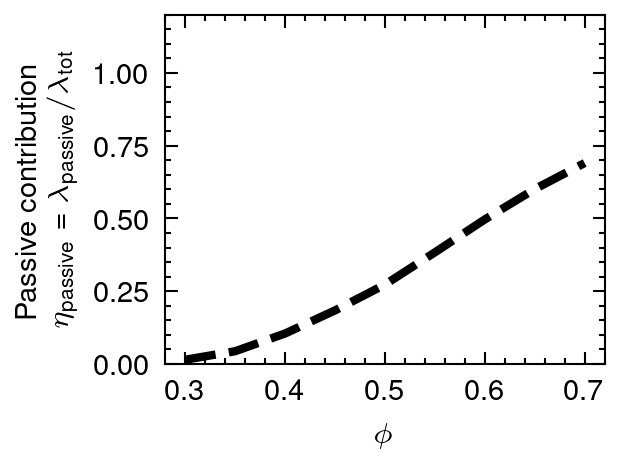

In [71]:
# Read the CSV and display its head and description
csv_contribution_df = pd.read_csv(csv_contribution_filename)

phi_values = np.linspace(0.3, 0.7, len(df))

# normalize
passive_norm = csv_contribution_df['mean_passive_contribution']

# Plot mean velocity vs φ
mm = 1 / 25.4
fig, ax = plt.subplots(figsize=(60 * 0.8 * mm, 48 * 0.8 * mm), dpi=300)
ax.plot(phi_values, passive_norm, '--', linewidth=2, color='black')
ax.set_xlabel('$\\phi$', fontsize=7)
ax.set_ylabel(r'Passive contribution' '\n' r'$\eta_{\text{passive}} = \lambda_{\text{passive}} / \lambda_{\text{tot}}$', fontsize=7)
ax.legend(fontsize=7)
ax.tick_params(axis='both', which='major', labelsize=7)
ax.set_ylim(0, 1.2)

plot_path = os.path.join(passive_save_path, "contribution.png")
fig.savefig(plot_path, dpi=300)

plt.show()

## include p

In [5]:
passive_save_path = os.path.join(save_path, "passive_contribute")
if not os.path.exists(passive_save_path):
    os.makedirs(passive_save_path)

mean_passive_order_list = []
mean_passive_contribution_list = []  # contribution of passive stress

for json_path in json_paths:
    print(f"Processing {json_path}...")

    ar = mp.archive.loadarchive(json_path)
    n = ar.num_frames
    lx, ly = ar.LX, ar.LY

    S_passive_stress_sum = None
    passive_contribution_sum = None  
    
    for ni in range(start_frame, end_frame):
        frame = ar._read_frame(ni)

        sigma_xx = frame.sigmaXX.reshape(lx, ly) - frame.sigma_bulk.reshape(lx, ly)
        sigma_yy = frame.sigmaYY.reshape(lx, ly) - frame.sigma_bulk.reshape(lx, ly)
        sigma_xy = frame.sigmaXY.reshape(lx, ly)
        sigma_yx = frame.sigmaYX.reshape(lx, ly)

        # sigma_passive_xx = frame.sigma_elastic_xx.reshape(lx, ly) + frame.sigma_bulk.reshape(lx, ly)
        # sigma_passive_yx = frame.sigma_elastic_yx.reshape(lx, ly)
        # sigma_passive_yy = -sigma_elastic_xx
    
        # sigma_passive_xx = sigma_elastic_xx
        # sigma_passive_yy = -sigma_elastic_xx
        # sigma_passive_xy = sigma_elastic_yx
        # sigma_passive_yx = sigma_elastic_yx
        
        sigma_active_xx = frame.sigma_active_xx.reshape(lx, ly)
        sigma_active_yx = frame.sigma_active_yx.reshape(lx, ly)
        
        # sigma_passive_xx = sigma_xx - sigma_active_xx - frame.sigma_bulk.reshape(lx, ly)
        # sigma_passive_yy = sigma_yy + sigma_active_xx - frame.sigma_bulk.reshape(lx, ly)
        sigma_passive_xx = sigma_xx - sigma_active_xx
        sigma_passive_yy = sigma_yy + sigma_active_xx
        sigma_passive_xy = sigma_xy - sigma_active_yx
        sigma_passive_yx = sigma_xy - sigma_active_yx
        
        I1_passive = sigma_passive_xx + sigma_passive_yy  # trace of the stress tensor
        tau_passive = sigma_passive_yx  # shear stress
        sigma_passive_avg = I1_passive / 2.0
        R_passive = np.sqrt(((sigma_passive_xx - sigma_passive_yy) / 2.0)**2 + tau_passive**2)
        sigma_passive_max = sigma_passive_avg + R_passive
        sigma_passive_min = sigma_passive_avg - R_passive
        theta_passive_max = 0.5 * np.arctan2(2 * tau_passive, sigma_passive_xx - sigma_passive_yy)
        theta_passive_max = np.mod(theta_passive_max, np.pi)
        
        I1 = sigma_xx + sigma_yy  # trace of the stress tensor
        tau = 0.5 * (sigma_xy + sigma_yx)  # shear stress
        sigma_avg = I1 / 2.0
        R = np.sqrt(((sigma_xx - sigma_yy) / 2.0)**2 + tau**2)
        sigma_max = sigma_avg + R

        eta_passive = np.abs(sigma_passive_max) / np.abs(sigma_max)

        r = 6
        y_grid, x_grid = np.ogrid[-r:r+1, -r:r+1]
        mask = (x_grid**2 + y_grid**2) <= r**2
        kernel = mask.astype(float)
        kernel /= kernel.sum()
        local_passive_cos = convolve(np.cos(2 * theta_passive_max), kernel, mode='reflect')
        local_passive_sin = convolve(np.sin(2 * theta_passive_max), kernel, mode='reflect')
        S_passive_stress = np.sqrt(local_passive_cos**2 + local_passive_sin**2)

        if S_passive_stress_sum is None:
            S_passive_stress_sum = S_passive_stress
            passive_contribution_sum = eta_passive
        else:
            S_passive_stress_sum += S_passive_stress
            passive_contribution_sum += eta_passive

    S_passive_avg = S_passive_stress_sum / frame_count
    passive_contribution_avg = passive_contribution_sum / frame_count

    overall_passive_contribution_mean = np.nanmean(passive_contribution_avg)
    mean_passive_contribution_list.append({"json_path": json_path, "mean_passive_contribution": overall_passive_contribution_mean})


    mm = 1 / 25.4
    fig, ax = plt.subplots(figsize=(48 * mm, 48 * mm), dpi=300)
    im = ax.imshow(S_passive_avg.T, origin='lower', cmap='cividis', alpha=1)
    cb = fig.colorbar(im, ax=ax, shrink=0.8)
    cb.set_label("S", fontsize=6)
    cb.ax.tick_params(labelsize=6)
    ax.set_xlabel('X', fontsize=7)
    ax.set_ylabel('Y', fontsize=7)
    ax.set_xticks(np.arange(0, lx + 1, 50))
    ax.set_yticks(np.arange(0, ly + 1, 50))
    ax.tick_params(axis='both', which='major', labelsize=7)
    
    json_name = os.path.basename(json_path.rstrip('/'))
    plot_filename = os.path.join(passive_save_path, f"{json_name}_passive-stress-order.png")
    fig.savefig(plot_filename, dpi=300)
    plt.close(fig)

    mean_passive_order_list.append({"json_path": json_path, "mean_passive_stress_order": np.nanmean(S_passive_avg)})

df_passive = pd.DataFrame(mean_passive_order_list)
csv_passive_stress_filename = os.path.join(passive_save_path, "mean_passive-stress_S.csv")
df_passive.to_csv(csv_passive_stress_filename, index=False)

df_contribution = pd.DataFrame(mean_passive_contribution_list)
csv_contribution_filename = os.path.join(passive_save_path, "mean_passive_contribution.csv")
df_contribution.to_csv(csv_contribution_filename, index=False)

print("Processing complete. CSV files saved at:", csv_passive_stress_filename, csv_contribution_filename)


Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-3...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-35...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-4...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-45...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-5...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-55...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-6...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-65...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-7...
Processing complete. CSV files saved at: /Volumes/Tianxiang/update/phi/phi_zeta2e-2/output_new/passive_contribute/mean_passive-stress_S.csv /Volumes/Tianxiang/update/phi/phi_zeta2e-2/output_new/passive_contribute/mean_passive_contribution.csv


# passive without bulk

In [6]:
passive_save_path = os.path.join(save_path, "passive_contribute_without_bulk")
if not os.path.exists(passive_save_path):
    os.makedirs(passive_save_path)

mean_passive_order_list = []
mean_passive_contribution_list = []  # contribution of passive stress

for json_path in json_paths:
    print(f"Processing {json_path}...")

    ar = mp.archive.loadarchive(json_path)
    n = ar.num_frames
    lx, ly = ar.LX, ar.LY

    S_passive_stress_sum = None
    passive_contribution_sum = None  
    
    for ni in range(start_frame, end_frame):
        frame = ar._read_frame(ni)

        sigma_xx = frame.sigmaXX.reshape(lx, ly)
        sigma_yy = frame.sigmaYY.reshape(lx, ly)
        sigma_xy = frame.sigmaXY.reshape(lx, ly)
        sigma_yx = frame.sigmaYX.reshape(lx, ly)

        # sigma_passive_xx = frame.sigma_elastic_xx.reshape(lx, ly) + frame.sigma_bulk.reshape(lx, ly)
        # sigma_passive_yx = frame.sigma_elastic_yx.reshape(lx, ly)
        # sigma_passive_yy = -sigma_elastic_xx
    
        # sigma_passive_xx = sigma_elastic_xx
        # sigma_passive_yy = -sigma_elastic_xx
        # sigma_passive_xy = sigma_elastic_yx
        # sigma_passive_yx = sigma_elastic_yx
        
        sigma_active_xx = frame.sigma_active_xx.reshape(lx, ly)
        sigma_active_yx = frame.sigma_active_yx.reshape(lx, ly)
        
        sigma_passive_xx = sigma_xx - sigma_active_xx - frame.sigma_bulk.reshape(lx, ly)
        sigma_passive_yy = sigma_yy + sigma_active_xx - frame.sigma_bulk.reshape(lx, ly)
        # sigma_passive_xx = sigma_xx - sigma_active_xx
        # sigma_passive_yy = sigma_yy + sigma_active_xx
        sigma_passive_xy = sigma_xy - sigma_active_yx
        sigma_passive_yx = sigma_xy - sigma_active_yx
        
        I1_passive = sigma_passive_xx + sigma_passive_yy  # trace of the stress tensor
        tau_passive = sigma_passive_yx  # shear stress
        sigma_passive_avg = I1_passive / 2.0
        R_passive = np.sqrt(((sigma_passive_xx - sigma_passive_yy) / 2.0)**2 + tau_passive**2)
        sigma_passive_max = sigma_passive_avg + R_passive
        sigma_passive_min = sigma_passive_avg - R_passive
        theta_passive_max = 0.5 * np.arctan2(2 * tau_passive, sigma_passive_xx - sigma_passive_yy)
        theta_passive_max = np.mod(theta_passive_max, np.pi)
        
        I1 = sigma_xx + sigma_yy  # trace of the stress tensor
        tau = 0.5 * (sigma_xy + sigma_yx)  # shear stress
        sigma_avg = I1 / 2.0
        R = np.sqrt(((sigma_xx - sigma_yy) / 2.0)**2 + tau**2)
        sigma_max = sigma_avg + R

        eta_passive = np.abs(sigma_passive_max) / np.abs(sigma_max)

        r = 6
        y_grid, x_grid = np.ogrid[-r:r+1, -r:r+1]
        mask = (x_grid**2 + y_grid**2) <= r**2
        kernel = mask.astype(float)
        kernel /= kernel.sum()
        local_passive_cos = convolve(np.cos(2 * theta_passive_max), kernel, mode='reflect')
        local_passive_sin = convolve(np.sin(2 * theta_passive_max), kernel, mode='reflect')
        S_passive_stress = np.sqrt(local_passive_cos**2 + local_passive_sin**2)

        if S_passive_stress_sum is None:
            S_passive_stress_sum = S_passive_stress
            passive_contribution_sum = eta_passive
        else:
            S_passive_stress_sum += S_passive_stress
            passive_contribution_sum += eta_passive

    S_passive_avg = S_passive_stress_sum / frame_count
    passive_contribution_avg = passive_contribution_sum / frame_count

    overall_passive_contribution_mean = np.nanmean(passive_contribution_avg)
    mean_passive_contribution_list.append({"json_path": json_path, "mean_passive_contribution": overall_passive_contribution_mean})


    mm = 1 / 25.4
    fig, ax = plt.subplots(figsize=(48 * mm, 48 * mm), dpi=300)
    im = ax.imshow(S_passive_avg.T, origin='lower', cmap='cividis', alpha=1)
    cb = fig.colorbar(im, ax=ax, shrink=0.8)
    cb.set_label("S", fontsize=6)
    cb.ax.tick_params(labelsize=6)
    ax.set_xlabel('X', fontsize=7)
    ax.set_ylabel('Y', fontsize=7)
    ax.set_xticks(np.arange(0, lx + 1, 50))
    ax.set_yticks(np.arange(0, ly + 1, 50))
    ax.tick_params(axis='both', which='major', labelsize=7)
    
    json_name = os.path.basename(json_path.rstrip('/'))
    plot_filename = os.path.join(passive_save_path, f"{json_name}_passive-stress-order.png")
    fig.savefig(plot_filename, dpi=300)
    plt.close(fig)

    mean_passive_order_list.append({"json_path": json_path, "mean_passive_stress_order": np.nanmean(S_passive_avg)})

df_passive = pd.DataFrame(mean_passive_order_list)
csv_passive_stress_filename = os.path.join(passive_save_path, "mean_passive-stress_S.csv")
df_passive.to_csv(csv_passive_stress_filename, index=False)

df_contribution = pd.DataFrame(mean_passive_contribution_list)
csv_contribution_filename = os.path.join(passive_save_path, "mean_passive_contribution.csv")
df_contribution.to_csv(csv_contribution_filename, index=False)

print("Processing complete. CSV files saved at:", csv_passive_stress_filename, csv_contribution_filename)


Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-3...


KeyboardInterrupt: 

## include p

In [7]:
passive_save_path = os.path.join(save_path, "passive_contribute_without_bulk")
if not os.path.exists(passive_save_path):
    os.makedirs(passive_save_path)

mean_passive_order_list = []
mean_passive_contribution_list = []  # contribution of passive stress

for json_path in json_paths:
    print(f"Processing {json_path}...")

    ar = mp.archive.loadarchive(json_path)
    n = ar.num_frames
    lx, ly = ar.LX, ar.LY

    S_passive_stress_sum = None
    passive_contribution_sum = None  
    
    for ni in range(start_frame, end_frame):
        frame = ar._read_frame(ni)

        sigma_xx = frame.sigmaXX.reshape(lx, ly) - frame.sigma_bulk.reshape(lx, ly)
        sigma_yy = frame.sigmaYY.reshape(lx, ly) - frame.sigma_bulk.reshape(lx, ly)
        sigma_xy = frame.sigmaXY.reshape(lx, ly)
        sigma_yx = frame.sigmaYX.reshape(lx, ly)

        # sigma_passive_xx = frame.sigma_elastic_xx.reshape(lx, ly) + frame.sigma_bulk.reshape(lx, ly)
        # sigma_passive_yx = frame.sigma_elastic_yx.reshape(lx, ly)
        # sigma_passive_yy = -sigma_elastic_xx
    
        # sigma_passive_xx = sigma_elastic_xx
        # sigma_passive_yy = -sigma_elastic_xx
        # sigma_passive_xy = sigma_elastic_yx
        # sigma_passive_yx = sigma_elastic_yx
        
        sigma_active_xx = frame.sigma_active_xx.reshape(lx, ly)
        sigma_active_yx = frame.sigma_active_yx.reshape(lx, ly)
        
        sigma_passive_xx = sigma_xx - sigma_active_xx - frame.sigma_bulk.reshape(lx, ly)
        sigma_passive_yy = sigma_yy + sigma_active_xx - frame.sigma_bulk.reshape(lx, ly)
        # sigma_passive_xx = sigma_xx - sigma_active_xx
        # sigma_passive_yy = sigma_yy + sigma_active_xx
        sigma_passive_xy = sigma_xy - sigma_active_yx
        sigma_passive_yx = sigma_xy - sigma_active_yx
        
        I1_passive = sigma_passive_xx + sigma_passive_yy  # trace of the stress tensor
        tau_passive = sigma_passive_yx  # shear stress
        sigma_passive_avg = I1_passive / 2.0
        R_passive = np.sqrt(((sigma_passive_xx - sigma_passive_yy) / 2.0)**2 + tau_passive**2)
        sigma_passive_max = sigma_passive_avg + R_passive
        sigma_passive_min = sigma_passive_avg - R_passive
        theta_passive_max = 0.5 * np.arctan2(2 * tau_passive, sigma_passive_xx - sigma_passive_yy)
        theta_passive_max = np.mod(theta_passive_max, np.pi)
        
        I1 = sigma_xx + sigma_yy  # trace of the stress tensor
        tau = 0.5 * (sigma_xy + sigma_yx)  # shear stress
        sigma_avg = I1 / 2.0
        R = np.sqrt(((sigma_xx - sigma_yy) / 2.0)**2 + tau**2)
        sigma_max = sigma_avg + R

        eta_passive = np.abs(sigma_passive_max) / np.abs(sigma_max)

        r = 6
        y_grid, x_grid = np.ogrid[-r:r+1, -r:r+1]
        mask = (x_grid**2 + y_grid**2) <= r**2
        kernel = mask.astype(float)
        kernel /= kernel.sum()
        local_passive_cos = convolve(np.cos(2 * theta_passive_max), kernel, mode='reflect')
        local_passive_sin = convolve(np.sin(2 * theta_passive_max), kernel, mode='reflect')
        S_passive_stress = np.sqrt(local_passive_cos**2 + local_passive_sin**2)

        if S_passive_stress_sum is None:
            S_passive_stress_sum = S_passive_stress
            passive_contribution_sum = eta_passive
        else:
            S_passive_stress_sum += S_passive_stress
            passive_contribution_sum += eta_passive

    S_passive_avg = S_passive_stress_sum / frame_count
    passive_contribution_avg = passive_contribution_sum / frame_count

    overall_passive_contribution_mean = np.nanmean(passive_contribution_avg)
    mean_passive_contribution_list.append({"json_path": json_path, "mean_passive_contribution": overall_passive_contribution_mean})


    mm = 1 / 25.4
    fig, ax = plt.subplots(figsize=(48 * mm, 48 * mm), dpi=300)
    im = ax.imshow(S_passive_avg.T, origin='lower', cmap='cividis', alpha=1)
    cb = fig.colorbar(im, ax=ax, shrink=0.8)
    cb.set_label("S", fontsize=6)
    cb.ax.tick_params(labelsize=6)
    ax.set_xlabel('X', fontsize=7)
    ax.set_ylabel('Y', fontsize=7)
    ax.set_xticks(np.arange(0, lx + 1, 50))
    ax.set_yticks(np.arange(0, ly + 1, 50))
    ax.tick_params(axis='both', which='major', labelsize=7)
    
    json_name = os.path.basename(json_path.rstrip('/'))
    plot_filename = os.path.join(passive_save_path, f"{json_name}_passive-stress-order.png")
    fig.savefig(plot_filename, dpi=300)
    plt.close(fig)

    mean_passive_order_list.append({"json_path": json_path, "mean_passive_stress_order": np.nanmean(S_passive_avg)})

df_passive = pd.DataFrame(mean_passive_order_list)
csv_passive_stress_filename = os.path.join(passive_save_path, "mean_passive-stress_S.csv")
df_passive.to_csv(csv_passive_stress_filename, index=False)

df_contribution = pd.DataFrame(mean_passive_contribution_list)
csv_contribution_filename = os.path.join(passive_save_path, "mean_passive_contribution.csv")
df_contribution.to_csv(csv_contribution_filename, index=False)

print("Processing complete. CSV files saved at:", csv_passive_stress_filename, csv_contribution_filename)


Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-3...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-35...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-4...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-45...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-5...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-55...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-6...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-65...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-7...
Processing complete. CSV files saved at: /Volumes/Tianxiang/update/phi/phi_zeta2e-2/output_new/passive_contribute_without_bulk/mean_passive-stress_S.csv /Volumes/Tianxiang/update/phi/phi_zeta2e-2/output_new/passive_contribute_without_bulk/mean_passive_contribution.csv


# J2, sigma_max, sigma_min

In [73]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import convolve

def compute_principal_stress(sigma_xx, sigma_yy, sigma_xy):
    """
    计算主应力的最大值、最小值和方向
    """
    trace = sigma_xx + sigma_yy
    det = sigma_xx * sigma_yy - sigma_xy ** 2
    delta = np.sqrt(trace ** 2 - 4 * det)

    sigma_max = (trace + delta) / 2
    sigma_min = (trace - delta) / 2

    theta = 0.5 * np.arctan2(2 * sigma_xy, sigma_xx - sigma_yy)  # 主应力方向
    return sigma_max, sigma_min, theta

# 创建存储目录
stress_save_path = os.path.join(save_path, "stress")
os.makedirs(stress_save_path, exist_ok=True)

mean_tot_stress_list = []  # 存储 sigma_max, sigma_min, J2

# 处理每个 JSON 文件
for json_path in json_paths:
    print(f"Processing {json_path}...")

    ar = mp.archive.loadarchive(json_path)
    n = ar.num_frames
    lx, ly = ar.LX, ar.LY

    # 存储累积值
    sigma_max_sum = np.zeros((lx, ly))
    sigma_min_sum = np.zeros((lx, ly))
    J2_sum = np.zeros((lx, ly))
    I1_sum = np.zeros((lx, ly))
    
    # 处理帧数据
    for ni in range(start_frame, end_frame):
        frame = ar._read_frame(ni)

        sigma_xx = frame.sigmaXX.reshape(lx, ly)
        sigma_yy = frame.sigmaYY.reshape(lx, ly)
        sigma_xy = 0.5 * (frame.sigmaXY.reshape(lx, ly) + frame.sigmaYX.reshape(lx, ly))
        
        # 计算 sigma_tot 的主应力
        sigma_max, sigma_min, _ = compute_principal_stress(sigma_xx, sigma_yy, sigma_xy)
        
        # 计算第二不变量 J2
        I1 = sigma_xx + sigma_yy  # trace of the stress tensor
        J2 = 0.5 * ((sigma_xx - I1/2.0)**2 + (sigma_yy - I1/2.0)**2 + 2 * sigma_xy**2)  # J2 不变量

        # 累加
        sigma_max_sum += sigma_max
        sigma_min_sum += sigma_min
        I1_sum += I1
        J2_sum += J2

    # 计算平均值
    mean_sigma_max = sigma_max_sum / frame_count
    mean_sigma_min = sigma_min_sum / frame_count
    mean_J2 = J2_sum / frame_count
    mean_I1 = I1_sum / frame_count

    # 存入列表
    mean_tot_stress_list.append({
        "json_path": json_path,
        "mean_sigma_max": np.nanmean(mean_sigma_max),
        "mean_sigma_min": np.nanmean(mean_sigma_min),
        "mean_J2": np.nanmean(mean_J2),
        "mean_I1": np.nanmean(mean_I1)
    })
    
    # 统一绘图函数
    def plot_stress_field(data, label, filename, vmin, vmax):
        fig, ax = plt.subplots(figsize=(48 / 25.4, 48 / 25.4), dpi=300)
        im = ax.imshow(data.T, origin='lower', cmap='YlGnBu_r', alpha=1, vmin=vmin, vmax=vmax)
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, orientation='vertical')
        cb.set_label(label, fontsize=6)
        cb.ax.tick_params(labelsize=6)
        # ax.set_xlabel('X', fontsize=7)
        # ax.set_ylabel('Y', fontsize=7)
        ax.set_xticks(np.arange(0, lx + 1, 50))
        ax.set_yticks(np.arange(0, ly + 1, 50))
        ax.tick_params(axis='both', which='major', labelsize=7)
        fig.savefig(filename, dpi=300)
        plt.close(fig)

    # 保存应力场图像
    json_name = os.path.basename(json_path.rstrip('/'))
    plot_stress_field(mean_sigma_max, r"$\sigma_{\max}$", os.path.join(stress_save_path, f"{json_name}_sigma1.png"), -0.002, 0.002)
    plot_stress_field(mean_sigma_min, r"$\sigma_{\min}$", os.path.join(stress_save_path, f"{json_name}_sigma2.png"), -0.002, 0.002)
    plot_stress_field(mean_J2, r"$J_2$", os.path.join(stress_save_path, f"{json_name}_J2.png"), 0, 3e-5)
    plot_stress_field(mean_I1, r"$I_1$", os.path.join(stress_save_path, f"{json_name}_I1.png"), 0, 0.004)

# 保存到 CSV
df_tot_stress = pd.DataFrame(mean_tot_stress_list)
csv_tot_stress_filename = os.path.join(stress_save_path, "mean_tot_stress.csv")
df_tot_stress.to_csv(csv_tot_stress_filename, index=False)

print("Processing complete. CSV file saved at:", csv_tot_stress_filename)


Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-3...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-35...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-4...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-45...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-5...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-55...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-6...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-65...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-7...
Processing complete. CSV file saved at: /Volumes/Tianxiang/update/phi/phi_zeta2e-2/output/stress/mean_tot_stress.csv


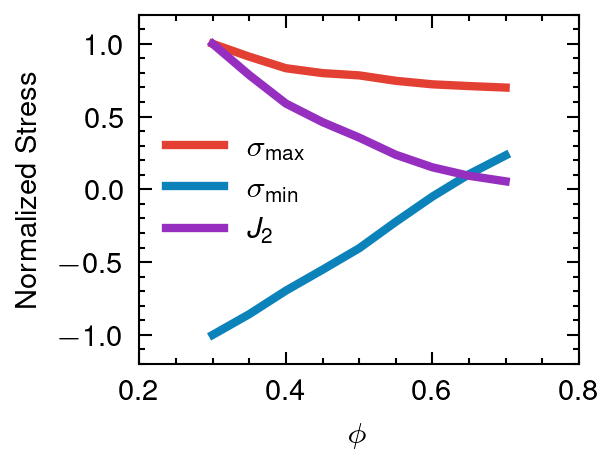

In [74]:
# Read the CSV file
csv_passive_df = pd.read_csv(csv_tot_stress_filename)

# Generate φ values based on the number of rows in the CSV
phi_values = np.linspace(0.3, 0.7, len(csv_passive_df))

# Normalize stress values
sigma_max = csv_passive_df['mean_sigma_max'] / abs(csv_passive_df['mean_sigma_max'].iloc[0])
sigma_min = csv_passive_df['mean_sigma_min'] / abs(csv_passive_df['mean_sigma_min'].iloc[0])
J2 = csv_passive_df['mean_J2'] / abs(csv_passive_df['mean_J2'].iloc[0])
I1 = csv_passive_df['mean_I1'] / abs(csv_passive_df['mean_I1'].iloc[0])

# Set figure size and resolution
mm = 1 / 25.4
fig, ax = plt.subplots(figsize=(60 * 0.8 * mm, 48 * 0.8 * mm), dpi=300)

# Plot normalized stresses against φ
ax.plot(phi_values, sigma_max, '-', linewidth=2, color='#E33F32', label=r'$\sigma_{\max}$')
ax.plot(phi_values, sigma_min, '-', linewidth=2, color='#0B82B9', label=r'$\sigma_{\min}$')
ax.plot(phi_values, J2, '-', linewidth=2, color='#962FBF', label=r'$J_2$')
# ax.plot(phi_values, I1, '-', linewidth=2, color='#FFC000', label=r'$I_1$')

# Set labels, legend, and axis properties
ax.set_xlabel(r'$\phi$', fontsize=7)
ax.set_ylabel('Normalized Stress', fontsize=7)
ax.legend(fontsize=7)
ax.tick_params(axis='both', which='major', labelsize=7)
ax.set_ylim(-1.2, 1.2)  # Dynamically adjust limits
ax.set_xlim(0.2,0.8)
# Save the plot
plot_path = os.path.join(stress_save_path, "stress.png")
fig.savefig(plot_path, dpi=300)

# Show the plot
plt.show()

# Bulk

In [75]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import convolve

def compute_principal_stress(sigma_xx, sigma_yy, sigma_xy):
    """
    计算主应力的最大值、最小值和方向
    """
    trace = sigma_xx + sigma_yy
    det = sigma_xx * sigma_yy - sigma_xy ** 2
    delta = np.sqrt(trace ** 2 - 4 * det)

    sigma_max = (trace + delta) / 2
    sigma_min = (trace - delta) / 2

    theta = 0.5 * np.arctan2(2 * sigma_xy, sigma_xx - sigma_yy)  # 主应力方向
    return sigma_max, sigma_min, theta

# 创建存储目录
bulk_save_path = os.path.join(save_path, "stress_bulk")
os.makedirs(bulk_save_path, exist_ok=True)

mean_bulk_stress_list = []  # 存储 sigma_bulk

# 处理每个 JSON 文件
for json_path in json_paths:
    print(f"Processing {json_path}...")

    # 提取 φ
    json_name = os.path.basename(json_path.rstrip('/'))
    phi = float(json_name.split('_')[0].replace("phi", "").replace("-", "."))

    # 计算 ζ
    zeta = 0.05 * (1 - phi)

    ar = mp.archive.loadarchive(json_path)
    n = ar.num_frames
    lx, ly = ar.LX, ar.LY

    # 存储累积值
    sigma_bulk_sum = np.zeros((lx, ly))

    # 处理帧数据
    for ni in range(start_frame, end_frame):
        frame = ar._read_frame(ni)      
        sigma_bulk = frame.sigma_bulk.reshape(lx, ly)
        # 累加
        sigma_bulk_sum += sigma_bulk


    # 计算平均值
    mean_sigma_bulk = sigma_bulk_sum / frame_count

    # 存入列表
    mean_bulk_stress_list.append({
        "json_path": json_path,
        "mean_bulk": np.nanmean(mean_sigma_bulk)
    })
    

    mm = 1 / 25.4
    fig, ax = plt.subplots(figsize=(40 * mm, 40 * mm), dpi=300)

    # Background image
    im = ax.imshow(mean_sigma_bulk.T, origin='lower', cmap='YlGnBu_r', alpha=1)

    # Remove axis labels and ticks
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # Colorbar settings (horizontal, below the plot)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.08, orientation='horizontal')
    cb.set_label(r"$P_{bulk}$", fontsize=6)
    cb.ax.tick_params(labelsize=6)

    # Save plot
    json_name = os.path.basename(json_path.rstrip('/'))
    plot_filename = os.path.join(bulk_save_path, f"{json_name}_bulk.png")
    fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.close(fig)


# 保存到 CSV
df_tot_bulk = pd.DataFrame(mean_bulk_stress_list)
csv_bulk_stress_filename = os.path.join(bulk_save_path, "mean_bulk.csv")
df_tot_bulk.to_csv(csv_bulk_stress_filename, index=False)

print("Processing complete. CSV file saved at:", csv_bulk_stress_filename)


Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-3...


Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-35...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-4...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-45...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-5...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-55...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-6...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-65...
Processing /Volumes/Tianxiang/update/phi/phi_zeta2e-2/phi0-7...
Processing complete. CSV file saved at: /Volumes/Tianxiang/update/phi/phi_zeta2e-2/output/stress_bulk/mean_bulk.csv


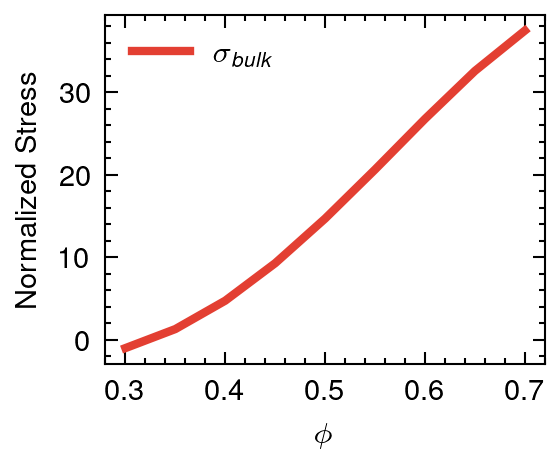

In [76]:
# Read the CSV file
csv_bulk_df = pd.read_csv(csv_bulk_stress_filename)

# Generate φ values based on the number of rows in the CSV
phi_values = np.linspace(0.3, 0.7, len(csv_bulk_df))

# Normalize stress values
sigma_bulk = csv_bulk_df['mean_bulk'] / abs(csv_bulk_df['mean_bulk'].iloc[0])

# Set figure size and resolution
mm = 1 / 25.4
fig, ax = plt.subplots(figsize=(60 * 0.8 * mm, 48 * 0.8 * mm), dpi=300)

# Plot normalized stresses against φ
ax.plot(phi_values, sigma_bulk, '-', linewidth=2, color='#E33F32', label=r'$\sigma_{bulk}$')

# Set labels, legend, and axis properties
ax.set_xlabel(r'$\phi$', fontsize=7)
ax.set_ylabel('Normalized Stress', fontsize=7)
ax.legend(fontsize=7)
ax.tick_params(axis='both', which='major', labelsize=7)
# ax.set_ylim(-1.2, 1.2)  # Dynamically adjust limits

# Save the plot
plot_path = os.path.join(bulk_save_path, "bulk.png")
fig.savefig(plot_path, dpi=300)

# Show the plot
plt.show()